In [1]:
from votekit.elections import FastSTV
from votekit import RankProfile, RankBallot

profile = RankProfile(
        ballots=tuple(
            [
                RankBallot(ranking=tuple(map(frozenset, [{"W"}])), weight=90),
                RankBallot(ranking=tuple(map(frozenset, [{"W"}, {"C"}])), weight=60),
                RankBallot(ranking=tuple(map(frozenset, [{"C"}])), weight=70),
                RankBallot(ranking=tuple(map(frozenset, [{"L"}])), weight=75),
                RankBallot(ranking=tuple(map(frozenset, [{"O"}])), weight=2),
            ]
        ),
        max_ranking_length=2,
    )

elec = FastSTV(profile, n_seats=2)
elec.get_score_df()

,Round 0,Round 1,Round 2,Round 3,Round 4
W,150.0,Elected,Elected,Elected,Elected
C,70.0,90.0,90.0,90.0,Elected
L,75.0,75.0,75.0,0.0,0.0
O,2.0,2.0,0.0,0.0,0.0
Quota,100.0,100.0,100.0,100.0,100.0


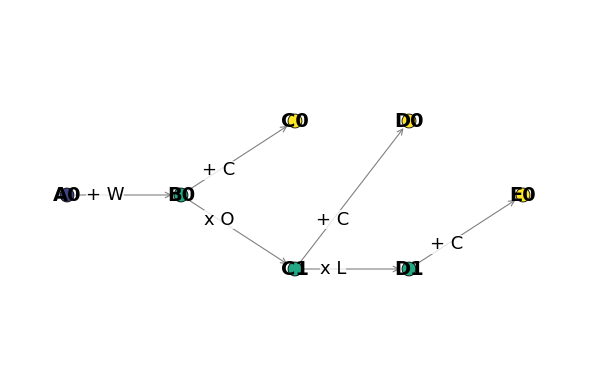

In [2]:
from src.wigm_graphs.graph_wigm import WIGMGraphConstructor
from src.plotting import plot_wigm_graph

constructor = WIGMGraphConstructor(profile, m=2, LAM = 14,)
constructor.build()

plot_wigm_graph(
    constructor,
    figsize=(6, 4),
    node_size=100,
    font_size=14,
    #label_edges=None,
    label_vertices=True,
    #lam_restriction=670,
    plot_horizontal=True,
    title="",
    seeded_build=True
    #title="Portland D2 (15 candidates, 3 seats, N_votes =42678, Margin=2000)"htop
)

In [3]:
# check the necessary sample size for a zero-noise audit

from src.test_processes import GlobalAuditDriver

driver = GlobalAuditDriver(
    audit_graph = constructor,
    noise_level = 0.02,
    noise_guess = 0.02/3,
    fractional_sample_size = 1,
    use_fallback = False)

driver.run(ballot_matrix = constructor.ballot_matrix)

Removed 5 duplicate compilers.
Audit diagnostic after 30 samples: 4 compilers remain below threshold (4/8 certified).
  B0-W2: M=0.589346, escape=ELECT 2:L, margin=candidate-to-candidate 1:C > 2:L
  C1-E1: M=0.589346, escape=ELIMINATE 1:C, margin=candidate-to-candidate 1:C > 2:L
  A0-W1: M=1.20574, escape=ELECT 1:C, margin=candidate-to-candidate 0:W > 1:C
  A0-E0: M=6.75913, escape=ELIMINATE 0:W, margin=candidate-above-quota 0:W >= quota
Audit diagnostic after 60 samples: 2 compilers remain below threshold (6/8 certified).
  B0-W2: M=1.19432, escape=ELECT 2:L, margin=candidate-to-candidate 1:C > 2:L
  C1-E1: M=1.19432, escape=ELIMINATE 1:C, margin=candidate-to-candidate 1:C > 2:L
Audit diagnostic after 90 samples: 2 compilers remain below threshold (6/8 certified).
  B0-W2: M=1.30521, escape=ELECT 2:L, margin=candidate-to-candidate 1:C > 2:L
  C1-E1: M=1.30521, escape=ELIMINATE 1:C, margin=candidate-to-candidate 1:C > 2:L
Audit diagnostic after 120 samples: 2 compilers remain below thr

/home/nardo/research/meek/src/test_processes/noise.py:40: RuntimeWarning: sample_size=297 is not smaller than total ballot weight 297.
  self._validate_sampling_scale(total_ballot_wt)


False

In [6]:
constructor.candidate_names

['W', 'C', 'L', 'O']

In [4]:
import numpy as np
import random

W_ballot = np.array([0, -127, -127], dtype=np.int8)
Wc_ballot = np.array([0, 1, -127], dtype=np.int8)
C_ballot = np.array([1, -127, -127], dtype=np.int8)
L_ballot = np.array([2, -127, -127], dtype=np.int8)
O_ballot = np.array([3, -127, -127], dtype=np.int8)

BAL_list = [W_ballot]*80 + [O_ballot]*10 + [Wc_ballot]*60 + [C_ballot]*70 + [L_ballot]*75 + [O_ballot]*2
CVR_list = [W_ballot]*90 + [Wc_ballot]*60 + [C_ballot]*70 + [L_ballot]*75 + [O_ballot]*2
zipped = list(zip(BAL_list, CVR_list))
random.shuffle(zipped)
BAL_list, CVR_list = zip(*zipped)
BAL_matrix = np.array(BAL_list, dtype=np.int8)
CVR_matrix = np.array(CVR_list, dtype=np.int8)

print(BAL_matrix[:5,:])
print(CVR_matrix[:5,:])

[[   0    1 -127]
 [   0 -127 -127]
 [   0    1 -127]
 [   1 -127 -127]
 [   2 -127 -127]]
[[   0    1 -127]
 [   0 -127 -127]
 [   0    1 -127]
 [   1 -127 -127]
 [   2 -127 -127]]


In [5]:
adversarial_driver = GlobalAuditDriver(
    audit_graph = constructor,
    noise_level = 0,
    noise_guess = 0.15,
    BAL=BAL_matrix,
    CVR=CVR_matrix,)

adversarial_driver.run()

Removed 5 duplicate compilers.
Audit diagnostic after 30 samples: 3 compilers remain below threshold (5/8 certified).
  B0-W2: M=1.08752, escape=ELECT 2:L, margin=candidate-to-candidate 1:C > 2:L
  C1-E1: M=1.08752, escape=ELIMINATE 1:C, margin=candidate-to-candidate 1:C > 2:L
  A0-E0: M=6.44423, escape=ELIMINATE 0:W, margin=candidate-above-quota 0:W >= quota
Audit diagnostic after 60 samples: 2 compilers remain below threshold (6/8 certified).
  B0-W2: M=1.1827, escape=ELECT 2:L, margin=candidate-to-candidate 1:C > 2:L
  C1-E1: M=1.1827, escape=ELIMINATE 1:C, margin=candidate-to-candidate 1:C > 2:L
Audit diagnostic after 90 samples: 2 compilers remain below threshold (6/8 certified).
  B0-W2: M=2.45274, escape=ELECT 2:L, margin=candidate-to-candidate 1:C > 2:L
  C1-E1: M=2.45274, escape=ELIMINATE 1:C, margin=candidate-to-candidate 1:C > 2:L
Audit diagnostic after 120 samples: 2 compilers remain below threshold (6/8 certified).
  B0-W2: M=2.6674, escape=ELECT 2:L, margin=candidate-to-c

/home/nardo/research/meek/src/test_processes/cobra.py:570: RuntimeWarning: A0-E0: Compiler configured to use fallback lambda. Using naive lambda.
  self._warn(f"{reason} Using naive lambda.")
/home/nardo/research/meek/src/test_processes/cobra.py:565: RuntimeWarning: A0-E0: Lambda -1.5640000000000047 is not positive. Using fallback lambda=1.9.
  self._warn(f"{reason} Using fallback lambda={DEFAULT_LAMBDA_VALUE}.")
/home/nardo/research/meek/src/test_processes/cobra.py:570: RuntimeWarning: A0-E1: Compiler configured to use fallback lambda. Using naive lambda.
  self._warn(f"{reason} Using naive lambda.")
/home/nardo/research/meek/src/test_processes/cobra.py:565: RuntimeWarning: A0-E1: Lambda -1.5640000000000047 is not positive. Using fallback lambda=1.9.
  self._warn(f"{reason} Using fallback lambda={DEFAULT_LAMBDA_VALUE}.")
/home/nardo/research/meek/src/test_processes/cobra.py:570: RuntimeWarning: A0-W1: Compiler configured to use fallback lambda. Using naive lambda.
  self._warn(f"{reas

False